In [1]:
from sys import displayhook

import matplotlib.pyplot as plt
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
dataframe_default = pd.read_csv("test_data.csv", index_col=0)
print(dataframe_default)
# dataframe_default["idx"] = dataframe_default["File"].split("/")[-1]["-4"]\
thingy = [x.split("/")[-1][:-4] for x in dataframe_default["File"]]
dataframe_default["idx"] = thingy
print(dataframe_default)
# dataframe_default = dataframe_default.assign(idx = lambda x: (x["File"].split("/")[-1]["-4"]))

                            File   Status    Runtime  Runlength  quality  seed
0       ./storage/default7/1.txt    UNSAT   966.8330          0        0    -1
1       ./storage/default7/4.txt    UNSAT   178.4680          0        0    -1
2       ./storage/default7/5.txt    UNSAT    85.3295          0        0    -1
3       ./storage/default7/6.txt    UNSAT  1647.0200          0        0    -1
4       ./storage/default7/7.txt    UNSAT  1521.0100          0        0    -1
..                           ...      ...        ...        ...      ...   ...
178  ./storage/default7/1856.txt  SUCCESS    36.2545          0        0    -1
179  ./storage/default7/1857.txt  SUCCESS  2084.8800          0        0    -1
180  ./storage/default7/1858.txt  SUCCESS   371.6770          0        0    -1
181  ./storage/default7/1869.txt  SUCCESS   149.1110          0        0    -1
182  ./storage/default7/1881.txt  SUCCESS    32.7798          0        0    -1

[183 rows x 6 columns]
                            

In [4]:
dataframe_new_config = pd.read_csv("storage_alice/Instance_multithread_new_testing/all_outputs.csv", index_col=0)
# print(dataframe_new_config)
other_thingy = [x.split("/")[-1][4:-3] for x in dataframe_new_config["File"]]
dataframe_new_config["idx"] = other_thingy
display(dataframe_new_config)

,Status,Runtime,Runlength,quality,seed,File,idx
0,UNSAT,113.333,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,5
1,UNSAT,232.760,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,4
2,UNSAT,193.947,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,18
3,UNSAT,488.250,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,15
4,UNSAT,504.630,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,11
...,...,...,...,...,...,...,...
179,SUCCESS,3743.550,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,1857
180,SUCCESS,6837.270,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,1642
181,SUCCESS,7345.030,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,1608
182,SUCCESS,5941.640,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,1840


In [5]:
diff1 = set(dataframe_new_config["idx"].unique()) - set(dataframe_default["idx"].unique())
diff2 = set(dataframe_default["idx"].unique()) - set(dataframe_new_config["idx"].unique())
print(diff1)
print(diff2)

{'1033'}
set()


In [6]:
# (dataframe_new_config["Status"] == "EXTERNALKILL")
dataframe_new_config["Status"].value_counts()

Status
SUCCESS         123
UNSAT            44
TIMEOUT           9
EXTERNALKILL      8
Name: count, dtype: int64

In [7]:
# TODO: so appreantly 1033 is missing from the default configs run... weird

In [8]:
# sns.displot(dataframe_new_config, x="Runtime")
# TODO: replace the extranakills with runtime...

dataframe_new_config.loc[(dataframe_new_config["Status"] == "EXTERNALKILL"), "Runtime"] = 9600
print(dataframe_new_config["Runtime"].describe())
display(dataframe_new_config.iloc[dataframe_new_config.index[(dataframe_new_config["Status"] == "EXTERNALKILL")]])

count     184.000000
mean     1922.138210
std      3058.145476
min         9.334510
25%       109.470750
50%       447.595500
75%      1778.445000
max      9601.510000
Name: Runtime, dtype: float64


,Status,Runtime,Runlength,quality,seed,File,idx
10,EXTERNALKILL,9600.0,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,27
11,EXTERNALKILL,9600.0,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,29
74,EXTERNALKILL,9600.0,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,509
78,EXTERNALKILL,9600.0,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,531
90,EXTERNALKILL,9600.0,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,628
106,EXTERNALKILL,9600.0,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,884
121,EXTERNALKILL,9600.0,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,1073
155,EXTERNALKILL,9600.0,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,1572


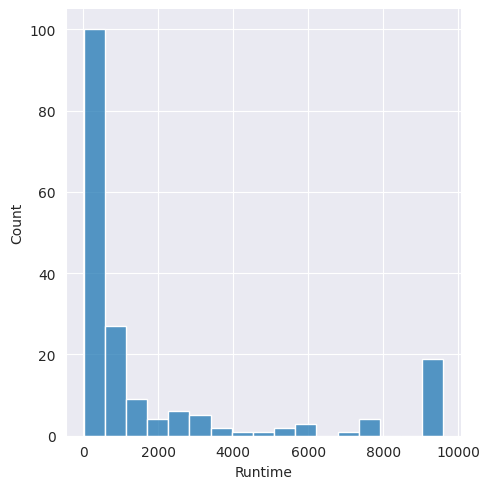

In [9]:
sns.displot(dataframe_new_config, x="Runtime")

# Comparing default to new

In [10]:
# TODO: could have just done an inner join i guess, that wuold already remove the not used keyl....
dataframe_new_config.drop(dataframe_new_config.index[(dataframe_new_config["idx"] == "1033")],axis=0,inplace=True)
# display(dataframe_new_config)

diff1 = set(dataframe_new_config["idx"].unique()) - set(dataframe_default["idx"].unique())
diff2 = set(dataframe_default["idx"].unique()) - set(dataframe_new_config["idx"].unique())
print(diff1)
print(diff2)

set()
set()


In [11]:
dataframe_new_config.rename(columns={"Runtime": "Runtime_new"}, inplace=True)
display(dataframe_new_config)

,Status,Runtime_new,Runlength,quality,seed,File,idx
0,UNSAT,113.333,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,5
1,UNSAT,232.760,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,4
2,UNSAT,193.947,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,18
3,UNSAT,488.250,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,15
4,UNSAT,504.630,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,11
...,...,...,...,...,...,...,...
179,SUCCESS,3743.550,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,1857
180,SUCCESS,6837.270,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,1642
181,SUCCESS,7345.030,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,1608
182,SUCCESS,5941.640,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,1840


In [12]:
dataframe_new_config["Status"].value_counts()

Status
SUCCESS         122
UNSAT            44
TIMEOUT           9
EXTERNALKILL      8
Name: count, dtype: int64

In [13]:
# print(dataframe_default["idx", "Runtime"])
# result_frame = pd.merge(dataframe_default["idx", "Runtime"], dataframe_new_config["idx", "Runtime_new"], how="left", on="idx")
result_frame = pd.merge(dataframe_default, dataframe_new_config, how="left", on="idx")
display(result_frame)
print(result_frame["Runtime_new"])

,File_x,Status_x,Runtime,Runlength_x,quality_x,seed_x,idx,Status_y,Runtime_new,Runlength_y,quality_y,seed_y,File_y
0,./storage/default7/1.txt,UNSAT,966.8330,0,0,-1,1,UNSAT,927.6210,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...
1,./storage/default7/4.txt,UNSAT,178.4680,0,0,-1,4,UNSAT,232.7600,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...
2,./storage/default7/5.txt,UNSAT,85.3295,0,0,-1,5,UNSAT,113.3330,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...
3,./storage/default7/6.txt,UNSAT,1647.0200,0,0,-1,6,UNSAT,608.4700,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...
4,./storage/default7/7.txt,UNSAT,1521.0100,0,0,-1,7,UNSAT,3290.0600,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,./storage/default7/1856.txt,SUCCESS,36.2545,0,0,-1,1856,SUCCESS,63.7699,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...
179,./storage/default7/1857.txt,SUCCESS,2084.8800,0,0,-1,1857,SUCCESS,3743.5500,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...
180,./storage/default7/1858.txt,SUCCESS,371.6770,0,0,-1,1858,SUCCESS,661.3970,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...
181,./storage/default7/1869.txt,SUCCESS,149.1110,0,0,-1,1869,SUCCESS,191.2680,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...


0       927.6210
1       232.7600
2       113.3330
3       608.4700
4      3290.0600
         ...    
178      63.7699
179    3743.5500
180     661.3970
181     191.2680
182      58.7296
Name: Runtime_new, Length: 183, dtype: float64


Text(0, 0.5, 'Runtime New Configuration')

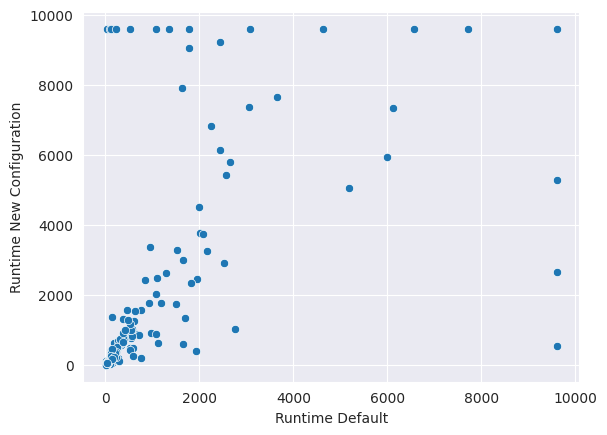

In [14]:
# result_frame.drop(result_frame.index[(result_frame["Status_y"] == "EXTERNALKILL")],axis=0,inplace=True)
ax = sns.scatterplot(data=result_frame, x="Runtime", y="Runtime_new")
# ax.set(xlabel='common xlabel', ylabel='common ylabel')
# plt.show()
plt.xlabel("Runtime Default")
plt.ylabel("Runtime New Configuration")

Text(0, 0.5, 'Runtime New Configuration')

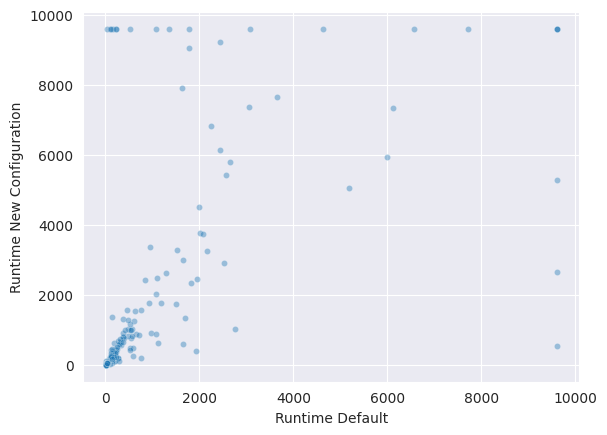

In [15]:

ax = sns.scatterplot(data=result_frame, x="Runtime", y="Runtime_new", alpha=0.4, s=20)
plt.xlabel("Runtime Default")
plt.ylabel("Runtime New Configuration")

If SMAC happens to choose the 3 on the right that time out on the default, but the new one does not, it makes sense that it will thinks its a much bettter configuration as in 1 timeout it could verify 5 to 20 fast instances, so the average gives a warped perspective.... COUP could actually help with this as will optimize first for the little box to the left, which is the most important, and also the place where the average is not completely wacky...

In [16]:
# result_frame.drop(result_frame.index[(result_frame["Status_y"] == "EXTERNALKILL")],axis=0,inplace=True)
# sns.scatterplot(data=result_frame, x="Runtime", y="Runtime_new")

# Plot test and train in different colors

In [17]:
train = []

with open("./aclib2/instances/mip/sets/SDPdMLPa-MIPVerify/training.txt") as file:
    line = file.readline()
    while line:
        # print(line)
        number = line.rstrip().split("/")[-1][4:-3]
        # print(number)
        train.append(f"{number}")
        line = file.readline()
    file.close()

print(train)

['1', '4', '5', '6', '7', '11', '12', '13', '14', '15', '18', '20', '21', '22', '23', '24', '26', '27', '28', '29', '30', '31', '32', '33', '35', '34', '63', '64', '93', '116', '120', '134', '145', '152', '196', '212', '218', '234', '242', '244', '246', '258', '301', '308', '319', '327', '339', '342', '350', '364', '367', '390', '436', '445', '449', '469', '479', '508', '509', '512', '531', '532', '537', '551', '554', '566', '572', '604', '606', '611', '620', '625', '628', '629', '630', '690', '724', '729', '739', '742', '782', '811', '830', '831', '833', '847', '878', '884', '891', '899', '901', '907']


In [18]:
file_ids = [i.split("/")[-1][4:-3] for i in result_frame["File_y"]]
result_frame["ID"] = file_ids

In [19]:
train_frame = result_frame[result_frame["ID"].isin(train)]
test_frame = result_frame[result_frame["ID"].isin(train) == False]

Text(0, 0.5, 'Runtime New Configuration')

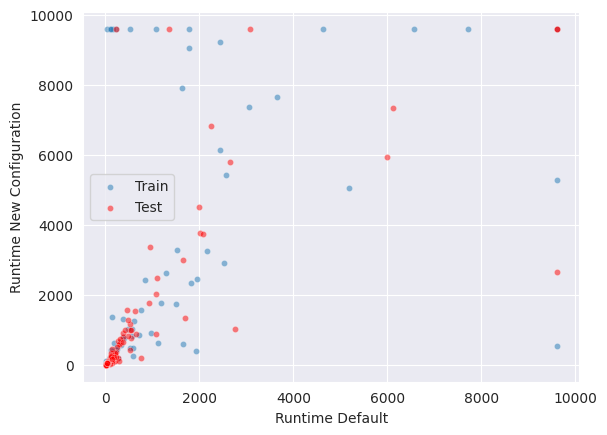

In [20]:

# ax = sns.scatterplot(data=result_frame, x="Runtime", y="Runtime_new", alpha=0.4, s=20)

ax = sns.scatterplot(x=train_frame["Runtime"], y=train_frame["Runtime_new"], alpha=0.5, s=20, label="Train")
sns.scatterplot(x=test_frame["Runtime"], y=test_frame["Runtime_new"], alpha=0.5, s=20, color="r", label="Test")

plt.xlabel("Runtime Default")
plt.ylabel("Runtime New Configuration")

In [21]:
print(len(train_frame))

92


In [30]:
print(np.mean(train_frame["Runtime"]))
print(np.mean(train_frame["Runtime_new"]))

1148.5518352173913
2437.081090217391


In [31]:
print(np.mean(test_frame["Runtime_new"]))

1418.7318726373624


Text(0, 0.5, 'Runtime New Configuration')

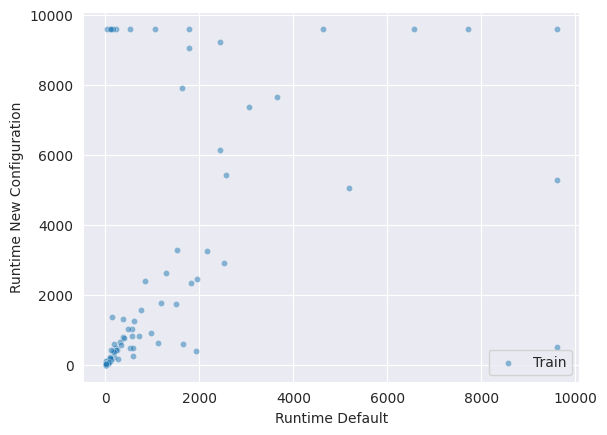

In [22]:
ax = sns.scatterplot(x=train_frame["Runtime"], y=train_frame["Runtime_new"], alpha=0.5, s=20, label="Train")
# sns.scatterplot(x=test_frame["Runtime"], y=test_frame["Runtime_new"], alpha=0.5, s=20, color="r", label="Test")

plt.xlabel("Runtime Default")
plt.ylabel("Runtime New Configuration")

# Comparing runtimes found by SMAC on both configurations

In [23]:
smac_randr = pd.read_csv("storage_alice/state-run1/runs_and_results-it20.csv")
instance_and_id = pd.read_csv("storage_alice/state-run1/instances.txt", header=None)
display(smac_randr)
display(instance_and_id)

,Run Number,Run History Configuration ID,Instance ID,Response Value (y),Censored?,Cutoff Time Used,Seed,Runtime,Run Length,Run Result Code,Run Quality,SMAC Iteration,SMAC Cumulative Runtime,Run Result,Additional Algorithm Run Data,Wall Clock Time,Unnamed: 16
0,1,1,20,552.41800,0,9600.00000,-1,552.4180,0.0,2,0.0,0,552.41800,UNSAT,NaN,556.644,NaN
1,2,1,72,418.22600,0,9600.00000,-1,418.2260,0.0,1,0.0,1,970.64400,SAT,NaN,419.918,NaN
2,3,2,20,114.52000,0,719.14600,-1,114.5200,0.0,2,0.0,1,1085.16400,UNSAT,NaN,115.289,NaN
3,4,2,72,1113.96510,1,1113.96510,-1,1114.1400,0.0,0,0.0,1,2199.30400,TIMEOUT,NaN,1119.796,NaN
4,5,1,4,1531.20000,0,9600.00000,-1,1531.2000,0.0,2,0.0,1,3730.50400,UNSAT,NaN,1536.613,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,121,29,34,2463.01000,0,9600.00000,-1,2463.0100,0.0,1,0.0,19,82425.15941,SAT,NaN,2471.943,NaN
121,122,37,27,57.12300,0,70.58367,-1,57.1230,0.0,1,0.0,19,82482.28241,SAT,NaN,57.506,NaN
122,123,29,41,205.05200,0,9600.00000,-1,205.0520,0.0,1,0.0,19,82687.33441,SAT,NaN,205.971,NaN
123,124,38,65,22.24044,1,22.24044,-1,23.1358,0.0,0,0.0,19,82710.47021,TIMEOUT,NaN,25.550,NaN


,0
0,/home/s3914038/thesis/Styx/aclib2/instances/mi...
1,/home/s3914038/thesis/Styx/aclib2/instances/mi...
2,/home/s3914038/thesis/Styx/aclib2/instances/mi...
3,/home/s3914038/thesis/Styx/aclib2/instances/mi...
4,/home/s3914038/thesis/Styx/aclib2/instances/mi...
...,...
87,/home/s3914038/thesis/Styx/aclib2/instances/mi...
88,/home/s3914038/thesis/Styx/aclib2/instances/mi...
89,/home/s3914038/thesis/Styx/aclib2/instances/mi...
90,/home/s3914038/thesis/Styx/aclib2/instances/mi...


In [24]:
smac_randr.columns

Index(['Run Number', 'Run History Configuration ID', 'Instance ID',
       'Response Value (y)', 'Censored?', 'Cutoff Time Used', 'Seed',
       'Runtime', 'Run Length', 'Run Result Code', 'Run Quality',
       'SMAC Iteration', 'SMAC Cumulative Runtime', 'Run Result',
       'Additional Algorithm Run Data', 'Wall Clock Time', 'Unnamed: 16'],
      dtype='object')

In [25]:
runs_default = smac_randr[smac_randr["Run History Configuration ID"] == 1]
runs_new = smac_randr[smac_randr["Run History Configuration ID"] == 29]
display(runs_default.head())
display(runs_new.head())

,Run Number,Run History Configuration ID,Instance ID,Response Value (y),Censored?,Cutoff Time Used,Seed,Runtime,Run Length,Run Result Code,Run Quality,SMAC Iteration,SMAC Cumulative Runtime,Run Result,Additional Algorithm Run Data,Wall Clock Time,Unnamed: 16
0,1,1,20,552.4180,0,9600.0,-1,552.4180,0.0,2,0.0,0,552.4180,UNSAT,NaN,556.644,NaN
1,2,1,72,418.2260,0,9600.0,-1,418.2260,0.0,1,0.0,1,970.6440,SAT,NaN,419.918,NaN
4,5,1,4,1531.2000,0,9600.0,-1,1531.2000,0.0,2,0.0,1,3730.5040,UNSAT,NaN,1536.613,NaN
8,9,1,65,16.2636,0,9600.0,-1,16.2636,0.0,1,0.0,2,6552.8536,SAT,NaN,16.705,NaN
13,14,1,69,60.8928,0,9600.0,-1,60.8928,0.0,1,0.0,2,9657.8115,SAT,NaN,61.331,NaN


,Run Number,Run History Configuration ID,Instance ID,Response Value (y),Censored?,Cutoff Time Used,Seed,Runtime,Run Length,Run Result Code,Run Quality,SMAC Iteration,SMAC Cumulative Runtime,Run Result,Additional Algorithm Run Data,Wall Clock Time,Unnamed: 16
71,72,29,54,50.1321,0,81.446601,-1,50.1321,0.0,1,0.0,15,50937.47926,SAT,NaN,50.791,NaN
72,73,29,68,23.0117,0,751.552660,-1,23.0117,0.0,1,0.0,15,50960.49096,SAT,NaN,23.472,NaN
73,74,29,6,241.2060,0,721.637451,-1,241.2060,0.0,2,0.0,15,51201.69696,UNSAT,NaN,242.323,NaN
74,75,29,91,1173.5900,0,9372.165440,-1,1173.5900,0.0,1,0.0,15,52375.28696,SAT,NaN,1177.806,NaN
75,76,29,43,14.0814,0,7846.498440,-1,14.0814,0.0,1,0.0,15,52389.36836,SAT,NaN,14.383,NaN


In [26]:
runs_default[["Instance ID", "Response Value (y)"]]

,Instance ID,Response Value (y)
0,20,552.41800
1,72,418.22600
4,4,1531.20000
8,65,16.26360
13,69,60.89280
15,78,32.81030
17,67,8.75031
19,48,582.63900
21,11,259.65100
23,68,57.60030


In [27]:
combined_frame = pd.merge(runs_default[["Instance ID", "Response Value (y)"]], runs_new[["Instance ID", "Response Value (y)"]], how="inner", on="Instance ID")
display(combined_frame.head())
print(len(combined_frame))
# print(combined_frame["Runtime_new"])

,Instance ID,Response Value (y)_x,Response Value (y)_y
0,20,552.4180,223.2980
1,72,418.2260,601.6110
2,4,1531.2000,312.6440
3,65,16.2636,16.3368
4,69,60.8928,46.1286


30


Text(0, 0.5, 'Runtime New Configuration')

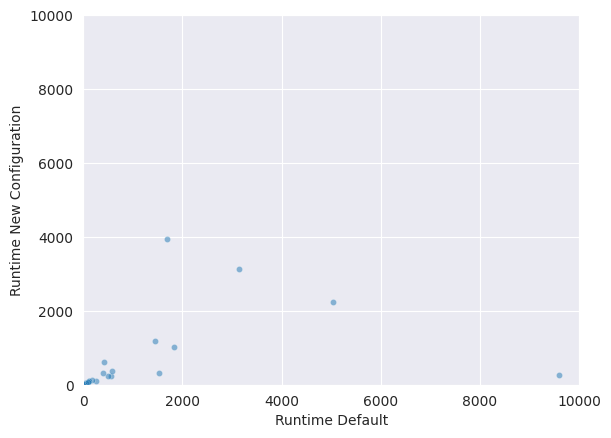

In [28]:
plto = sns.scatterplot(data=combined_frame, x="Response Value (y)_x", y="Response Value (y)_y", alpha=0.5, s=20,)
plto.set_xlim(0, 10_000)
plto.set_ylim(0, 10_000)
plt.xlabel("Runtime Default")
plt.ylabel("Runtime New Configuration")

In [29]:
print(np.mean(combined_frame["Response Value (y)_x"]))
print(np.mean(combined_frame["Response Value (y)_y"]))

931.0058220000002
488.93869966666665


In [170]:
# Indexing is -1 here, which is awful, but well, nevermind is was issue with header....
inst_lis = list(combined_frame["Instance ID"] -1)
# print(inst_lis)
# print(len(instance_and_id))
inst_paths = instance_and_id.iloc[inst_lis]
# display(inst_paths)
# for x in inst_paths[0]:
#     print(x)
inst_nums = [x.split("/")[-1][4:-3] for x in inst_paths[0]]
print(inst_nums)

['29', '625', '6', '554', '606', '729', '572', '342', '18', '604', '620', '469', '512', '628', '830', '327', '11', '532', '4', '445', '847', '364', '301', '93', '901', '629', '63', '899', '33', '690']


In [171]:
# display(result_frame[["File_x", "Runtime", "File_y", "Runtime_new"]])
small_frame = result_frame[["File_x", "Runtime", "File_y", "Runtime_new"]].copy()
small_frame["x"] = [x.split("/")[-1][:-4] for x in small_frame["File_x"]]
small_frame["y"] = [x.split("/")[-1][4:-3] for x in small_frame["File_y"]]
display(small_frame.head())


,File_x,Runtime,File_y,Runtime_new,x,y
0,./storage/default7/1.txt,966.8330,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,927.621,1,1
1,./storage/default7/4.txt,178.4680,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,232.760,4,4
2,./storage/default7/5.txt,85.3295,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,113.333,5,5
3,./storage/default7/6.txt,1647.0200,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,608.470,6,6
4,./storage/default7/7.txt,1521.0100,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,3290.060,7,7


In [172]:
sliced_frame = small_frame[small_frame["x"].isin(inst_nums)]
display(sliced_frame.tail())

,File_x,Runtime,File_y,Runtime_new,x,y
102,./storage/default7/729.txt,27.7273,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,32.8919,729,729
107,./storage/default7/830.txt,3056.5900,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,7367.2300,830,830
110,./storage/default7/847.txt,102.0220,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,213.5600,847,847
114,./storage/default7/899.txt,22.6034,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,50.5748,899,899
115,./storage/default7/901.txt,1290.0000,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,2642.0200,901,901


(0.0, 10000.0)

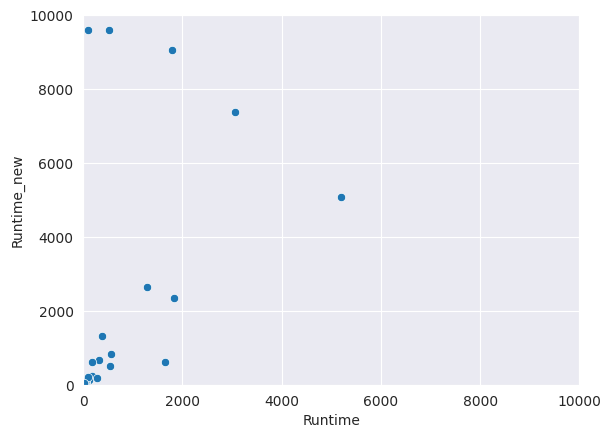

In [173]:
plto = sns.scatterplot(data=sliced_frame, x="Runtime", y="Runtime_new")
plto.set_xlim(0, 10_000)
plto.set_ylim(0, 10_000)

# What?

In [174]:
combined_frame["x"] = inst_nums
display(combined_frame)

,Instance ID,Response Value (y)_x,Response Value (y)_y,x
0,20,552.41800,223.29800,29
1,72,418.22600,601.61100,625
2,4,1531.20000,312.64400,6
3,65,16.26360,16.33680,554
4,69,60.89280,46.12860,606
5,78,32.81030,16.81430,729
6,67,8.75031,8.30126,572
7,48,582.63900,359.93100,342
8,11,259.65100,108.33100,18
9,68,57.60030,23.01170,604


In [175]:
combined_frame = pd.merge(combined_frame, sliced_frame, how="inner", on="x")
display(combined_frame.head())
print(len(combined_frame))

,Instance ID,Response Value (y)_x,Response Value (y)_y,x,File_x,Runtime,File_y,Runtime_new,y
0,20,552.4180,223.2980,29,./storage/default7/29.txt,519.8460,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,9600.0000,29
1,72,418.2260,601.6110,625,./storage/default7/625.txt,384.2620,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,1320.5200,625
2,4,1531.2000,312.6440,6,./storage/default7/6.txt,1647.0200,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,608.4700,6
3,65,16.2636,16.3368,554,./storage/default7/554.txt,14.1022,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,31.8910,554
4,69,60.8928,46.1286,606,./storage/default7/606.txt,50.0270,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,98.5235,606


30


(0.0, 10000.0)

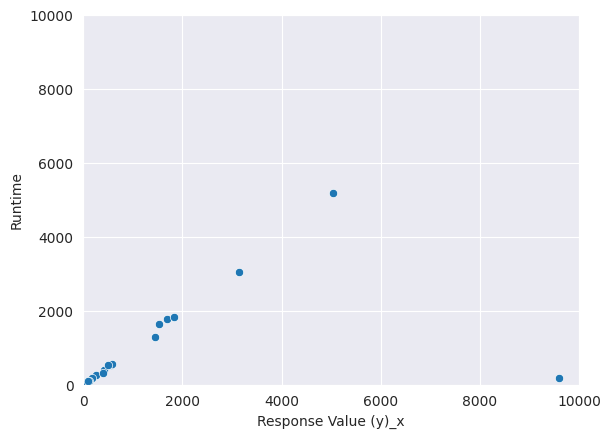

In [176]:
plto = sns.scatterplot(data=combined_frame, x="Response Value (y)_x", y="Runtime")
plto.set_xlim(0, 10_000)
plto.set_ylim(0, 10_000)

Okay, so its all machine specifc.... very machine specific... the x axis is the runtimes on alice, while the y axis is from the verification run on my own laptop. This is ducked on so many levels. Maybe I made a mistake in the indexing (I really hope)

In [ ]:
# TODO: currently the verification is runnning on alice again, so we can compare the default to the local default and see iff they are similar. If not it likely means the runsovler needs to be recompiled....
# TODO: check the seed
# TODO: Im stupid, some runtimes will have been cut off earlier then 9600 seconds because the default is faster.... but chekK
# LOOKING at the plot this doesnt seem to be the case..

No linear line is back now, smac starts it's indexing at 1... wich is weird but okay. I guess the config IDs also do this so fair enoug, but man that gave me a heart attack. Also the one that times out on the new one but is good my own machine is probably the externakill I assume (It's actually CRASHED in the files..)

This also explains why it finds a better one. The on the default craches, which is why that timeout point does not exist after comparison to the run on my machine, which is why it doesnt show up in the plots above. That timeout has such a large impact n the average that 29 overtakes 1, even though 29 is actually much worse of a configuration. So this craching really is a major issue.

Still some unexplained oddities as the points dont allign very well, but again that is likely hardware specific. We should just be consistent in the hardware we use and in the runsolver (compile it to the specific machine).